<a href="https://colab.research.google.com/github/Aditi-Chopra/ju-cmater-project/blob/main/Practice_Data_Pre_processing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [9]:
!pip install scikeras

In [1]:
import numpy as np  # importing NumPy for working with array
import pandas as pd   # for data manipulation, analysis and cleaning
from sklearn.impute import SimpleImputer  # for data imputation
from sklearn.preprocessing import StandardScaler, OneHotEncoder
# for data scaling
from sklearn.compose import ColumnTransformer
from sklearn.feature_selection import VarianceThreshold

In [2]:
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Train Dataset.csv')
#Loading data into pandas datframe

In [3]:
# Step 1: Defining Target / y-variable: risk
target_col = 'risk'   # avoids hardcoding the column name in multiple places

if target_col in df.columns:  # checks whether the column 'risk' exists
    y = df[target_col].copy()   # extracts and saves the 'risk' column from the
                                # df in 'y' variable
    X = df.drop(columns=[target_col]).copy()  # deletes the 'risk' column from
                                              # df and saves all remaining
                                              # columns into a new df called X
    print(f"Step 1: Target '{target_col}' isolated. Features shape: {X.shape}")
    # prints a confirmation message that target variable was successfully
    # located and isolated
else:
    raise KeyError(f"Target column '{target_col}' not found.")

Step 1: Target 'risk' isolated. Features shape: (162634, 102)


In [4]:
# Step 2:
cols_to_drop = [
    'event_id', 'mission_id',
    'max_risk_estimate', 'max_risk_scaling',
    't_time_lastob_start', 't_time_lastob_end',
    'c_time_lastob_start', 'c_time_lastob_end',
]

# Ensure columns are dropped from X, not df
dropped_cols = [col for col in cols_to_drop if col in X.columns]
X.drop(columns=dropped_cols, inplace=True)

In [5]:
# Step 3A: Clean Missing Data (Imputation):
# Identifying which columns are text/categories(ordinal) and which are numbers

# Extracting text/categorical and numerical columns from the data frame into
# 2 separate lists
cat_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()
num_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Filling in missing data/ Imputating with median values
num_imputer = SimpleImputer(strategy='median')
if num_cols:# checks if num_cols is not empty -> evaluates to true if at least
             # 1 column is non-empty
    X[num_cols] = num_imputer.fit_transform(X[num_cols]) # combines the fit() and
                                                       # transform() methods

cat_imputer = SimpleImputer(strategy='most_frequent')
if cat_cols:
    X[cat_cols] = cat_imputer.fit_transform(X[cat_cols])

In [6]:
# Step 3B: Encode Categories and Scale Numbers
# 1. Defining the simultaeneous processing rules
preprocessor = ColumnTransformer(   # it routes specific columns to specific
                                    # transformers
    transformers= [
        ('num', StandardScaler(), num_cols),
        # Standardises every column in num_cols to have a mean of 0 and a
        # standard deviation of 1
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False),
         cat_cols)
        # takes every text/categorical column in cat_cols and converts them into
        # binary dummy vairables (0s and 1s)
        # handle_unknown -> to prevent the program from crashing if a new
                          # unknown category is introduced - it encodes it all
                          # as zeros instead of crashing the program
    ],
    remainder='passthrough'   # to keep the remiander columns, overriding
)

# 2. Applying the transformation to the feature set
X_processed = preprocessor.fit_transform(X)   # fit learns the underlying
# patterns, transform physically applies those to calculated changes to the data
# outputting the final result into the X_processed variable

In [7]:
# Step 4:
# 1. Convert the preprocessed array into a Pandas DataFrame with feature names
feature_names = preprocessor.get_feature_names_out()  # a scikit-learn method
# retrieves the new, accurate column names generated by ColumnTransformer
X_scaled = pd.DataFrame(X_processed, columns=feature_names)
# Converts the raw 2D NumPy matrix into a Pandas df and assigns the
# feature_names generated to the columns

# 2. Define variance threshold
variance_threshold = 0.01   # establishes the cut-off limit for variance
# if a column is almost entirely a single value, it's variance will be 0
# this cut-off limit marks any such low variance variables as useless for
# machine learning

# Option A: Direct Pandas approach (Efficient equivalent to np.diag(cov_matrix))
feature_variances = X_scaled.var() # calculates the variance for every single
# column in the df simultaeneously -> numeric columns were already scaled with
# StandardScaler, their vairances are exactly 1.0
# this method evaluates the one-hot encoded categorical columns

nzv_cols = feature_variances[feature_variances < variance_threshold].index.tolist()
# creates a True/False mask, extracts the actual names of the columns that
# evaluated to True and converts those extracted column names into a standard
# python list so it can be passed to the drop() function

X_final = X_scaled.drop(columns=nzv_cols) # creates the final dataset by
# deleting all the low-variance columns stored in the nzv_cols list from the
# dataset

print(f"Features removed due to low variance (< {variance_threshold}): {len(nzv_cols)}")
print(f"Names of removed features: {nzv_cols}")
print(f"Final feature matrix shape: {X_final.shape}")

Features removed due to low variance (< 0.01): 1
Names of removed features: ['cat__c_object_type_TBA']
Final feature matrix shape: (162634, 97)


In [13]:
import pandas as pd
# for data manipulation and tabular operations
import numpy as np
# for high-performance numerical operations and matrices
import matplotlib.pyplot as plt
# for rendering static visual charts
import seaborn as sns
# for drawing statistical graphics and heatmaps
from scipy.stats import pearsonr
# for calculating Pearson correlation coefficient and p-value significance
import scipy.cluster.hierarchy as sch
# for hierarchical clustering and generating dendrograms
from statsmodels.stats.outliers_influence import variance_inflation_factor
# for measuring Variance Inflation Factor (VIF)
from sklearn.model_selection import train_test_split
# for splitting data into training and testing sets
from sklearn.metrics import accuracy_score, f1_score, classification_report
# for evaluating model performance
from tensorflow.keras.models import Sequential
# for initializing a linear stack of layers for the neural network
from tensorflow.keras.layers import LSTM, Dense, Dropout
# for adding specific layer types to the neural network
from tensorflow.keras.regularizers import l1
# for applying L1 regularization (Lasso-like feature selection) to weights
from tensorflow.keras.callbacks import EarlyStopping
# for stopping training when a monitored metric has stopped improving
from scikeras.wrappers import KerasClassifier
# for wrapping Keras models to make them compatible with scikit-learn tools
import shap
# for interpreting the machine learning model using SHAP values
import warnings
# for controlling warning messages
warnings.filterwarnings('ignore')
# suppresses non-critical warning messages in the output

# Assuming 'X_final' and 'y' are the final outputs from your Step 4, and 'df' is your original dataset
X_df = X_final.copy()  # copies the preprocessed feature matrix to prevent overwriting original data

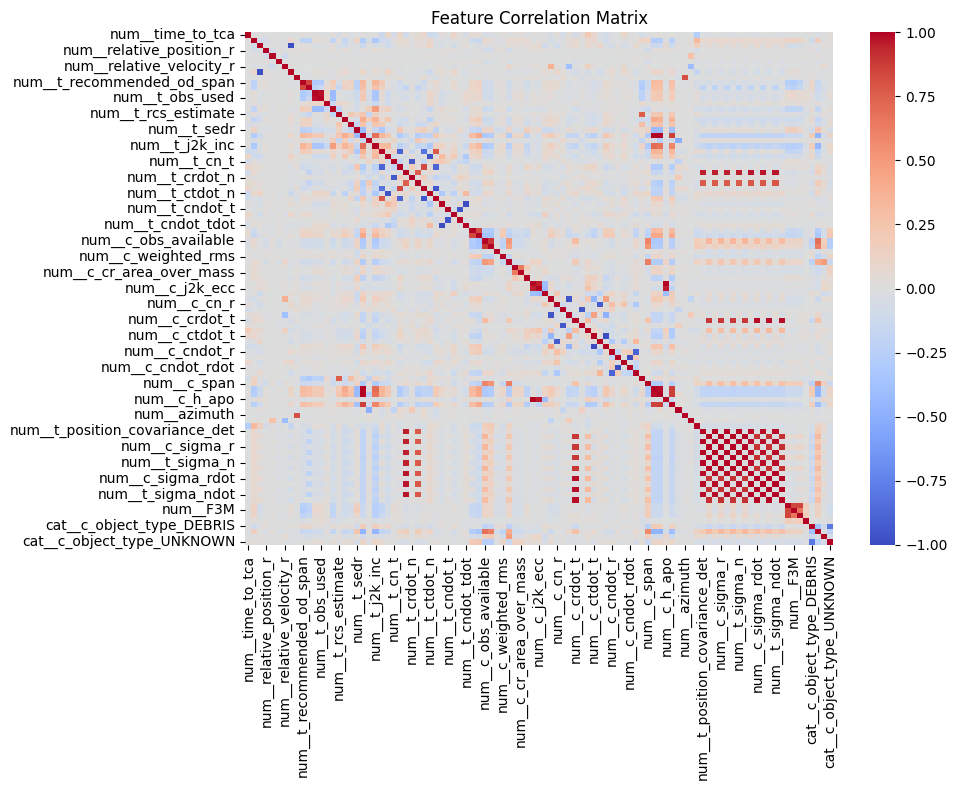

ValueError: Could not interpret value `num__time_to_tca` for `x`. An entry with this name does not appear in `data`.

<Figure size 600x300 with 0 Axes>

In [14]:
# 1. Variable Correlation Matrix with p-value significance
def compute_correlation_with_pvalues(dataframe):  # defines function to compute correlation and significance matrices
    cols = dataframe.columns  # retrieves list of column names
    corr_matrix = pd.DataFrame(index=cols, columns=cols, dtype=float)  # initializes empty matrix for correlation values
    p_matrix = pd.DataFrame(index=cols, columns=cols, dtype=float)  # initializes empty matrix for p-values

    for col1 in cols:  # loops through each feature as the primary column
        for col2 in cols:  # loops through each feature as the comparison column
            r, p = pearsonr(dataframe[col1], dataframe[col2])  # calculates Pearson r correlation and two-tailed p-value
            corr_matrix.loc[col1, col2] = r  # assigns calculated correlation value to matrix
            p_matrix.loc[col1, col2] = p  # assigns calculated p-value to matrix

    return corr_matrix, p_matrix  # returns both correlation and p-value dataframes

corr_matrix, p_matrix = compute_correlation_with_pvalues(X_df)  # executes correlation and significance calculation

# 2. Variable Plot to see correlation trends
plt.figure(figsize=(10, 8))  # creates matplotlib figure with specified dimensions
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', vmin=-1, vmax=1)  # renders correlation heatmap without text to avoid clutter
plt.title("Feature Correlation Matrix")  # adds chart title
plt.tight_layout()  # adjusts layout padding
plt.savefig("correlation_heatmap.png")  # saves plot image
plt.show()  # displays heatmap plot

# Plotting feature distributions/trends against target variable (using first 3 columns as an example)
for col in X_df.columns[:3]:  # loops through top 3 features for trend visualization
    plt.figure(figsize=(6, 3))  # creates small figure container
    sns.kdeplot(data=df, x=col, hue=target_col, common_norm=False, palette='Set2')  # plots kernel density estimate by risk category
    plt.title(f"Trend & Distribution of {col} across {target_col}")  # adds descriptive plot title
    plt.tight_layout()  # adjusts padding
    plt.show()  # displays density distribution plot

# 3. Hierarchical Clustering Dendrogram
distance_matrix = 1 - np.abs(corr_matrix)  # calculates distance metric where high correlation gives near-zero distance
linkage = sch.linkage(sch.distance.squareform(distance_matrix), method='ward')  # computes Ward's hierarchical clustering linkage

plt.figure(figsize=(10, 6))  # creates figure container for dendrogram
dendrogram = sch.dendrogram(linkage, labels=X_df.columns, orientation='top', leaf_rotation=90)  # plots hierarchical tree diagram
plt.title("Hierarchical Feature Clustering Dendrogram")  # sets title for dendrogram
plt.ylabel("Distance (1 - |Correlation|)")  # labels y-axis
plt.tight_layout()  # adjusts plot spacing
plt.savefig("feature_dendrogram.png")  # saves output image
plt.show()  # displays dendrogram chart

# 4. Removing Redundant Features
high_corr_threshold = 0.8  # sets correlation threshold
alpha_sig = 0.05  # sets statistical significance level (5%)

upper_tri_corr = corr_matrix.abs().where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))  # isolates upper triangle of correlations
upper_tri_p = p_matrix.where(np.triu(np.ones(p_matrix.shape), k=1).astype(bool))  # isolates upper triangle of p-values

to_drop_corr = []  # initializes list for redundant feature collection
for col in upper_tri_corr.columns:  # iterates through feature columns
    # checks if correlation exceeds threshold AND p-value indicates statistical significance
    if any((upper_tri_corr[col] > high_corr_threshold) & (upper_tri_p[col] < alpha_sig)):
        to_drop_corr.append(col)  # appends feature to drop list

print(f"Features dropped due to significant high correlation: {to_drop_corr}")  # logs dropped features
X_df_reduced = X_df.drop(columns=to_drop_corr)  # drops redundant highly-correlated features

# 5. Variance Inflation Factor (VIF) Screening
def calculate_vif(dataframe):  # defines function for calculating VIF scores
    vif_data = pd.DataFrame()  # creates blank dataframe container
    vif_data["Feature"] = dataframe.columns  # assigns feature names column
    vif_data["VIF"] = [variance_inflation_factor(dataframe.values, i) for i in range(dataframe.shape[1])]  # calculates VIF iteratively
    return vif_data  # returns populated VIF dataframe

vif_threshold = 10.0  # defines strict VIF cutoff threshold
vif_df = calculate_vif(X_df_reduced)  # computes VIF on reduced feature set

to_drop_vif = vif_df[vif_df['VIF'] > vif_threshold]['Feature'].tolist()  # filters out features with VIF > 10
print(f"Features dropped due to high VIF (> {vif_threshold}): {to_drop_vif}")  # logs dropped VIF features

X_step5 = X_df_reduced.drop(columns=to_drop_vif)  # creates final step 5 feature set
final_feature_names = X_step5.columns.tolist()  # extracts final active feature names for neural network training